In [ ]:
import pandas as pd

df = pd.read_csv("laptop_price.csv", encoding='latin1')
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


# Data Analysis

In [ ]:
df = df.drop(columns=['Product', 'Company', 'laptop_ID'])

In [ ]:
#Encoding the ScreenHeight and ScreenWidth
df = df.join(pd.get_dummies(df['TypeName'].astype(str))).drop('TypeName', axis=1)
df['ScreenResolution'] = df['ScreenResolution'].apply(lambda x: x.split(" ")[-1])
df['ScreenHeight'] = df['ScreenResolution'].apply(lambda x: x.split("x")[1]).astype(int)
df['ScreenWidth'] = df['ScreenResolution'].apply(lambda x: x.split("x")[0]).astype(int)

df = df.drop(columns=['ScreenResolution'])

In [ ]:
df['Cpu_brand'] = df['Cpu'].apply(lambda x: x.split(' ')[0])
df = df.join(pd.get_dummies(df['Cpu_brand'].astype(str))).drop('Cpu_brand', axis=1)
df['Cpu_ghz'] = df['Cpu'].apply(lambda x: x.split(' ')[-1])
df['Cpu_ghz'] = df['Cpu_ghz'].apply(lambda x: x.replace('GHz', ''))
df['Cpu_ghz'] = df['Cpu_ghz'].astype(float)


df['Ram'] = df['Ram'].apply(lambda x: x.replace('GB', ''))
df['Ram'] = df['Ram'].astype(int)

df = df.drop(columns=['Cpu'])


In [ ]:
df.head()

,Inches,Ram,Memory,Gpu,OpSys,Weight,Price_euros,2 in 1 Convertible,Gaming,Netbook,Notebook,Ultrabook,Workstation,ScreenHeight,ScreenWidth,AMD,Intel,Samsung,Cpu_ghz
0,13.3,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,False,False,False,False,True,False,1600,2560,False,True,False,2.3
1,13.3,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,False,False,False,False,True,False,900,1440,False,True,False,1.8
2,15.6,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,False,False,False,True,False,False,1080,1920,False,True,False,2.5
3,15.4,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,False,False,False,False,True,False,1800,2880,False,True,False,2.7
4,13.3,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,False,False,False,False,True,False,1600,2560,False,True,False,3.1


In [ ]:
def memory_convertor(value):
  #memory in GBs

  value = value.split(' ')[0]
  if 'TB' in value:
    return float(value.replace('TB', '')) * 1024
  else :
    return float(value.replace('GB', ''))

In [ ]:
df['Memory'] = df['Memory'].apply(memory_convertor)

In [ ]:
# Weight Conversion
df['Weight'] = df['Weight'].apply(lambda x: x.replace('kg', ''))
df['Weight'] = df['Weight'].astype(float)

In [ ]:
df['OpSys'] = df['OpSys'].apply(lambda x: x.split(' ')[0])
df = df.join(pd.get_dummies(df['OpSys'].astype(str))).drop('OpSys', axis=1)

In [ ]:
df['Gpu'] = df['Gpu'].apply(lambda x: x.split(' ')[0])
df = df.join(pd.get_dummies(df['Gpu'].astype(str), prefix='Gpu')).drop('Gpu', axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Inches              1303 non-null   float64
 1   Ram                 1303 non-null   int64  
 2   Memory              1303 non-null   float64
 3   Weight              1303 non-null   float64
 4   Price_euros         1303 non-null   float64
 5   2 in 1 Convertible  1303 non-null   bool   
 6   Gaming              1303 non-null   bool   
 7   Netbook             1303 non-null   bool   
 8   Notebook            1303 non-null   bool   
 9   Ultrabook           1303 non-null   bool   
 10  Workstation         1303 non-null   bool   
 11  ScreenHeight        1303 non-null   int64  
 12  ScreenWidth         1303 non-null   int64  
 13  AMD                 1303 non-null   bool   
 14  Intel               1303 non-null   bool   
 15  Samsung             1303 non-null   bool   
 16  Cpu_gh

In [ ]:
df.head()

,Inches,Ram,Memory,Weight,Price_euros,2 in 1 Convertible,Gaming,Netbook,Notebook,Ultrabook,...,Chrome,Linux,Mac,No,Windows,macOS,Gpu_AMD,Gpu_ARM,Gpu_Intel,Gpu_Nvidia
0,13.3,8,128.0,1.37,1339.69,False,False,False,False,True,...,False,False,False,False,False,True,False,False,True,False
1,13.3,8,128.0,1.34,898.94,False,False,False,False,True,...,False,False,False,False,False,True,False,False,True,False
2,15.6,8,256.0,1.86,575.00,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
3,15.4,16,512.0,1.83,2537.45,False,False,False,False,True,...,False,False,False,False,False,True,True,False,False,False
4,13.3,8,256.0,1.37,1803.60,False,False,False,False,True,...,False,False,False,False,False,True,False,False,True,False


array([[<Axes: title={'center': 'Inches'}>,
        <Axes: title={'center': 'Ram'}>,
        <Axes: title={'center': 'Memory'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Price_euros'}>,
        <Axes: title={'center': 'ScreenHeight'}>],
       [<Axes: title={'center': 'ScreenWidth'}>,
        <Axes: title={'center': 'Cpu_ghz'}>, <Axes: >]], dtype=object)

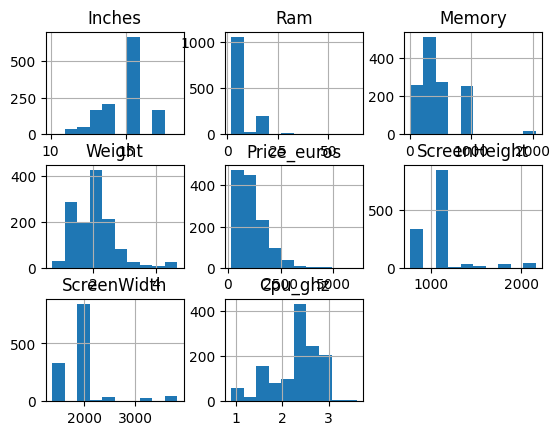

In [ ]:
df.hist()

In [ ]:
target_correlations = df.corr()['Price_euros'].apply(abs).sort_values()

In [ ]:
target_correlations

,Price_euros
Mac,0.015656
Samsung,0.018431
Gpu_ARM,0.018431
Android,0.038700
Inches,0.068197
2 in 1 Convertible,0.072675
macOS,0.089928
Netbook,0.097572
Chrome,0.118684
Memory,0.125363


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X, y = df.drop("Price_euros", axis=1), df["Price_euros"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
forest = RandomForestRegressor(n_jobs=-1)

forest.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1)

In [ ]:
y_pred = forest.predict(X_test)

forest.score(X_test, y_test)
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, y_pred)
print(rmse)

296.67175373492626


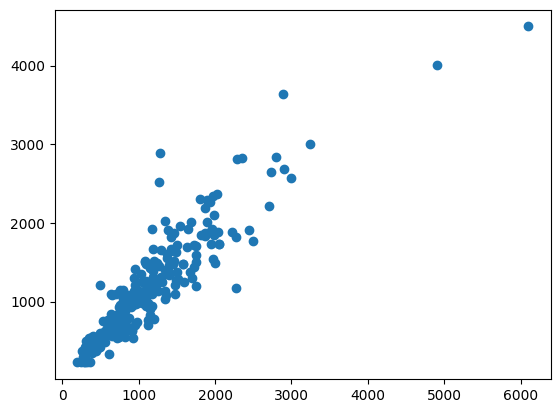

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)